In [1]:
import torch

In [ ]:
torch.cuda.is_available()

In [17]:
tensor_fp64 = torch.randn(10, 100, dtype=torch.float64)
tensor_fp32 = tensor_fp64.to(torch.float32)

torch.result_type(tensor_fp64, tensor_fp32)
results = torch.max(torch.abs(tensor_fp64 - tensor_fp32))
print(results)

tensor(1.1828e-07, dtype=torch.float64)


In [25]:
torch.manual_seed(0)
tensor_fp64 = torch.randn(10, 100, dtype=torch.float64)
tensor_fp32 = tensor_fp64.to(torch.float32)

# do comparison in fp64
diff = (tensor_fp64-tensor_fp32.to(torch.float64))
mae = diff.abs().mean()
max_abs_error = diff.abs().max()

# relative errors
denom = torch.abs(tensor_fp64).clamp_min(1e-6) # clamp_min to avoid division by zero
rel_error = diff.abs() / denom
mean_rel_error = rel_error.mean()
max_rel_error = rel_error.max()

mean_rel_error_wo_upcast = torch.mean(torch.abs(tensor_fp64 - tensor_fp32) / (torch.abs(tensor_fp64).clamp_min(1e-6)))

print(f"MAE: {mae.item():.6e}") # mae.item() to get the scalar value
print(f"Max Absolute Error: {max_abs_error.item():.6e}")
print(f"Mean Relative Error: {mean_rel_error.item():.6e}")
print(f"Mean relative error without upcast: {mean_rel_error_wo_upcast.item():.6e}")
print(f"Max Relative Error: {max_rel_error.item():.6e}")

eps = 1e-6 # for relative metrics to avoid divide-by-zero

# Assume you already ran two models/pipelines:
# y64 computed in float64 (double), y32 computed in float32 (float)
# Make sure both are on the same device
y64 = tensor_fp64.to(torch.float64)
y32 = tensor_fp64.to(torch.float32)

# Do comparisons in float64
diff = (y64 - y32.to(torch.float64))
mae  = diff.abs().mean()
mse  = (diff**2).mean()
max_abs_err = diff.abs().max()

# Relative errors
denom = y64.abs().clamp_min(eps)
rel = diff.abs() / denom
mean_rel_err = rel.mean()
max_rel_err  = rel.max()

print(f"MAE: {mae.item():.6e}")
print(f"MSE: {mse.item():.6e}")
print(f"Max abs err: {max_abs_err.item():.6e}")
print(f"Mean rel err: {mean_rel_err.item():.6e}")
print(f"Max  rel err: {max_rel_err.item():.6e}")



MAE: 1.741556e-08
Max Absolute Error: 1.181384e-07
Mean Relative Error: 2.171572e-08
Mean relative error without upcast: 2.171572e-08
Max Relative Error: 5.745297e-08
MAE: 1.741556e-08
MSE: 6.723848e-16
Max abs err: 1.181384e-07
Mean rel err: 2.171572e-08
Max  rel err: 5.745297e-08


gemini generated

In [21]:
import torch

torch.manual_seed(0)

tensor_ref = torch.randn(10, 100, dtype=torch.float64)
tensor_fp32 = tensor_ref.to(torch.float32)

# Calculate Mean Squared Error (MSE)
mse = torch.nn.functional.mse_loss(tensor_ref, tensor_fp32)
print(f"Mean Squared Error: {mse.item()}")

# Calculate Relative Error (using a small epsilon to avoid division by zero)
epsilon = 1e-8
relative_error = torch.mean(torch.abs(tensor_ref - tensor_fp32) / (torch.abs(tensor_ref) + epsilon))
print(f"Mean Relative Error: {relative_error.item()}")

Mean Squared Error: 6.723848357620362e-16
Mean Relative Error: 2.1715717364152656e-08


/homes/ab3149/miniconda3/envs/myvenv/lib/python3.10/site-packages/torch/profiler/profiler.py:445: UserWarning: Profiler won't be using warmup, this can skew profiler results
  warn("Profiler won't be using warmup, this can skew profiler results")
/homes/ab3149/miniconda3/envs/myvenv/lib/python3.10/site-packages/torch/profiler/profiler.py:445: UserWarning: Profiler won't be using warmup, this can skew profiler results
  warn("Profiler won't be using warmup, this can skew profiler results")


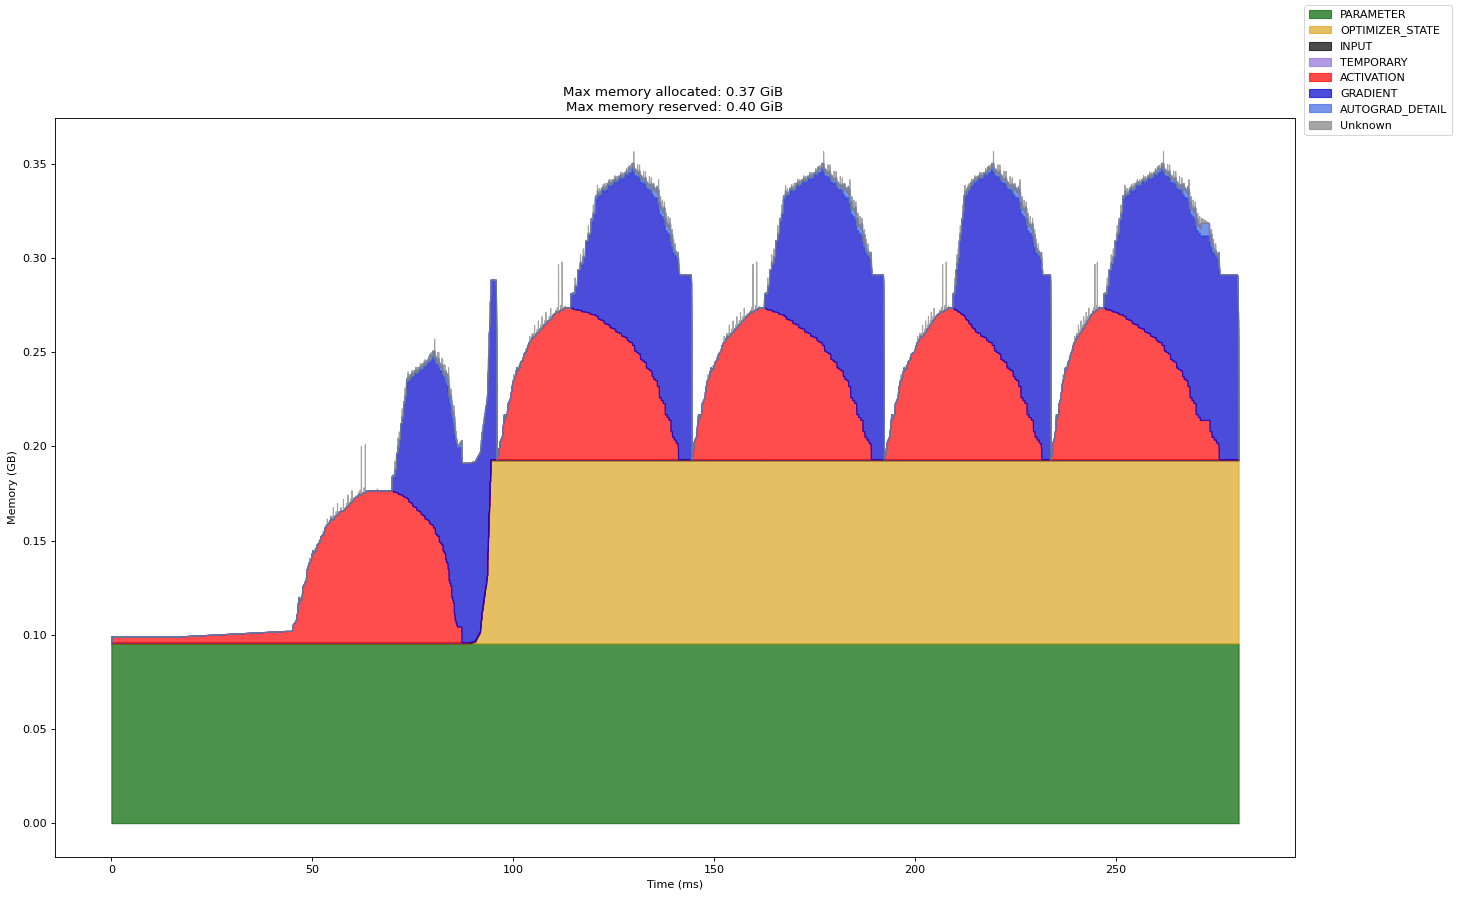

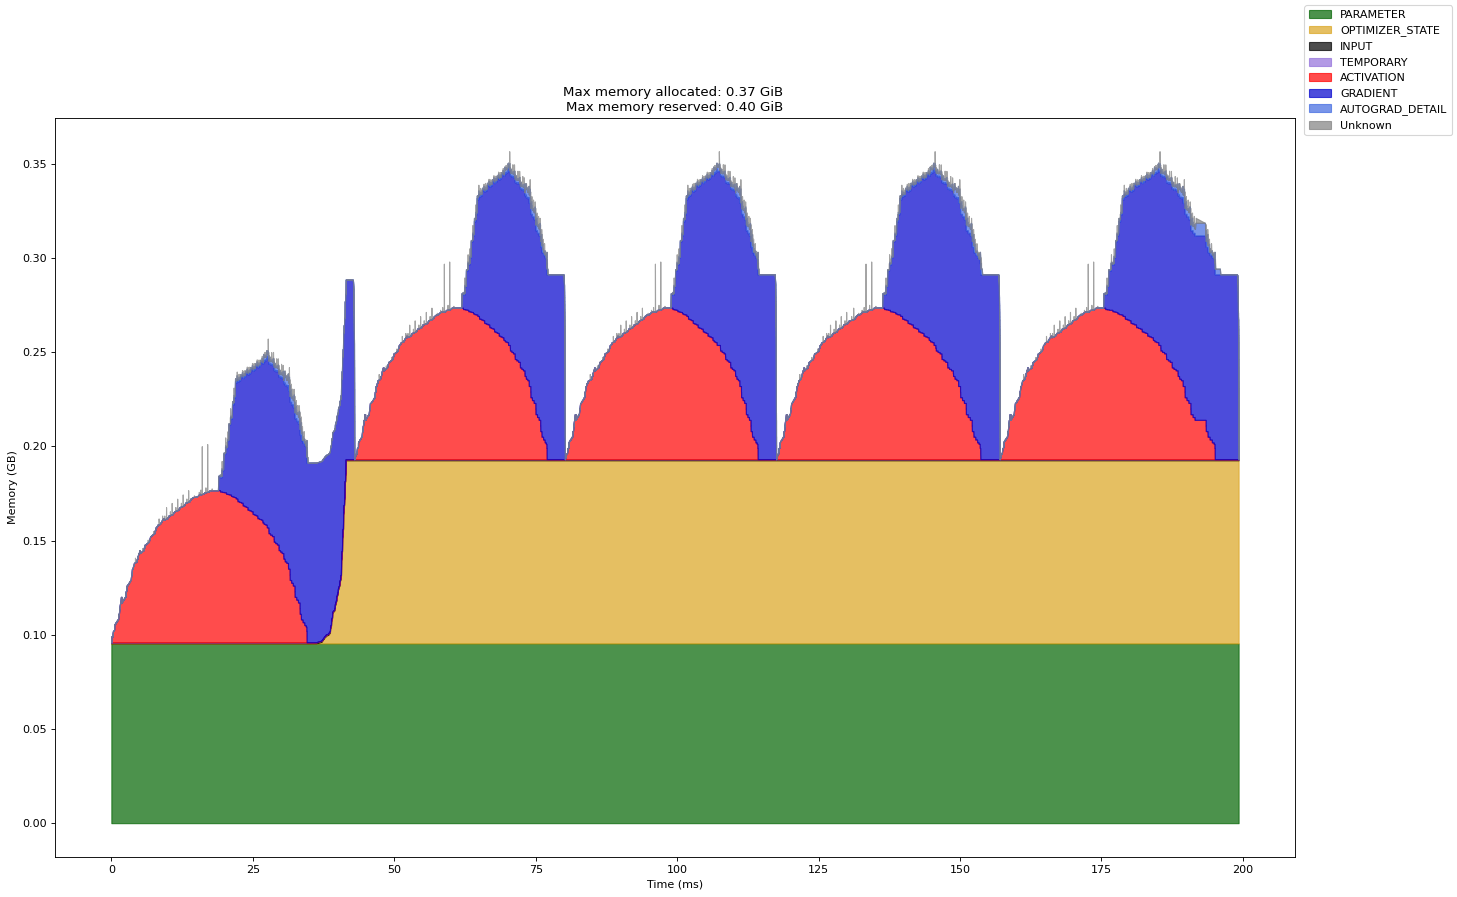

In [27]:
# (c) Meta Platforms, Inc. and affiliates. 
import logging
import socket
from datetime import datetime, timedelta

import torch

from torch.autograd.profiler import record_function
from torchvision import models

logging.basicConfig(
   format="%(levelname)s:%(asctime)s %(message)s",
   level=logging.INFO,
   datefmt="%Y-%m-%d %H:%M:%S",
)
logger: logging.Logger = logging.getLogger(__name__)
logger.setLevel(level=logging.INFO)

TIME_FORMAT_STR: str = "%b_%d_%H_%M_%S"

def trace_handler(prof: torch.profiler.profile):
   # Prefix for file names.
   host_name = socket.gethostname()
   timestamp = datetime.now().strftime(TIME_FORMAT_STR)
   file_prefix = f"{host_name}_{timestamp}"

   # Construct the trace file.
   prof.export_chrome_trace(f"{file_prefix}.json.gz")

   # Construct the memory timeline file.
   prof.export_memory_timeline(f"{file_prefix}.html", device="cuda:0")

def run_resnet50(num_iters=5, device="cuda:0"):
   model = models.resnet50().to(device=device)
   inputs = torch.randn(1, 3, 224, 224, device=device)
   labels = torch.rand_like(model(inputs))
   optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
   loss_fn = torch.nn.CrossEntropyLoss()

   with torch.profiler.profile(
       activities=[
           torch.profiler.ProfilerActivity.CPU,
           torch.profiler.ProfilerActivity.CUDA,
       ],
       schedule=torch.profiler.schedule(wait=0, warmup=0, active=6, repeat=1),
       record_shapes=True,
       profile_memory=True,
       with_stack=True,
       on_trace_ready=trace_handler,
   ) as prof:
       for _ in range(num_iters):
           prof.step()
           with record_function("## forward ##"):
               pred = model(inputs)

           with record_function("## backward ##"):
               loss_fn(pred, labels).backward()

           with record_function("## optimizer ##"):
               optimizer.step()
               optimizer.zero_grad(set_to_none=True)

if __name__ == "__main__":
    # Warm up
    run_resnet50()
    # Run the resnet50 model
    run_resnet50()